In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

start_date = "2024-01-01"

gold = yf.download("GC=F", start=start_date, auto_adjust=False, progress=False)
silver = yf.download("SI=F", start=start_date, auto_adjust=False, progress=False)

In [3]:
gold = yf.download("GC=F", start="2024-01-01", auto_adjust=False, progress=False)
silver = yf.download("SI=F", start="2024-01-01", auto_adjust=False, progress=False)

# Flatten columns if needed
gold.columns = [col[0] if isinstance(col, tuple) else col for col in gold.columns]
silver.columns = [col[0] if isinstance(col, tuple) else col for col in silver.columns]

gold_close = gold["Close"].squeeze().rename("gold_close")
silver_close = silver["Close"].squeeze().rename("silver_close")

df = pd.concat([gold_close, silver_close], axis=1).dropna().copy()
df["gold_silver_ratio"] = df["gold_close"] / df["silver_close"]

df.tail()

,gold_close,silver_close,gold_silver_ratio
Date,,,
2026-04-27,4675.399902,75.002998,62.336173
2026-04-28,4591.500000,73.205002,62.721124
2026-04-29,4545.200195,71.569000,63.507946
2026-04-30,4614.700195,73.533997,62.756010
2026-05-01,4626.399902,74.474998,62.120175


In [4]:
window = 20

df["ratio_mean_20"] = df["gold_silver_ratio"].rolling(window).mean()
df["ratio_std_20"] = df["gold_silver_ratio"].rolling(window).std()
df["ratio_zscore_20"] = (
    (df["gold_silver_ratio"] - df["ratio_mean_20"]) / df["ratio_std_20"]
)

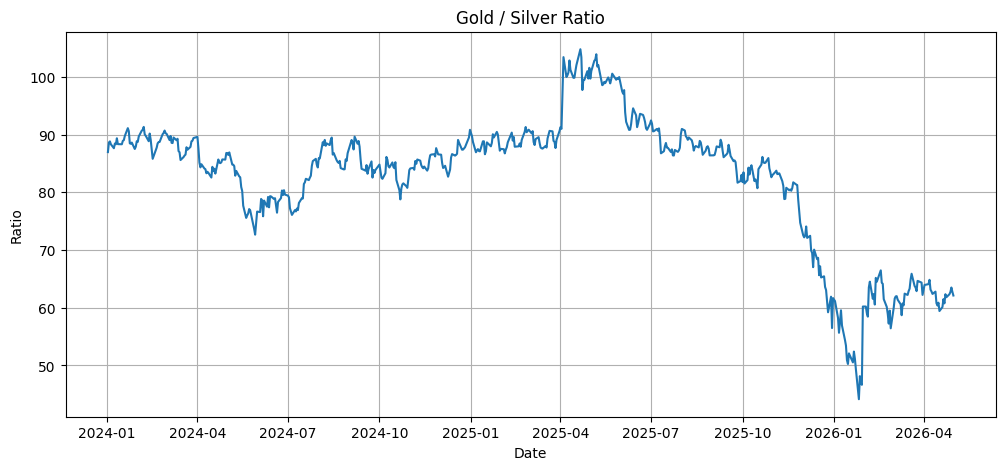

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["gold_silver_ratio"])
plt.title("Gold / Silver Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.show()

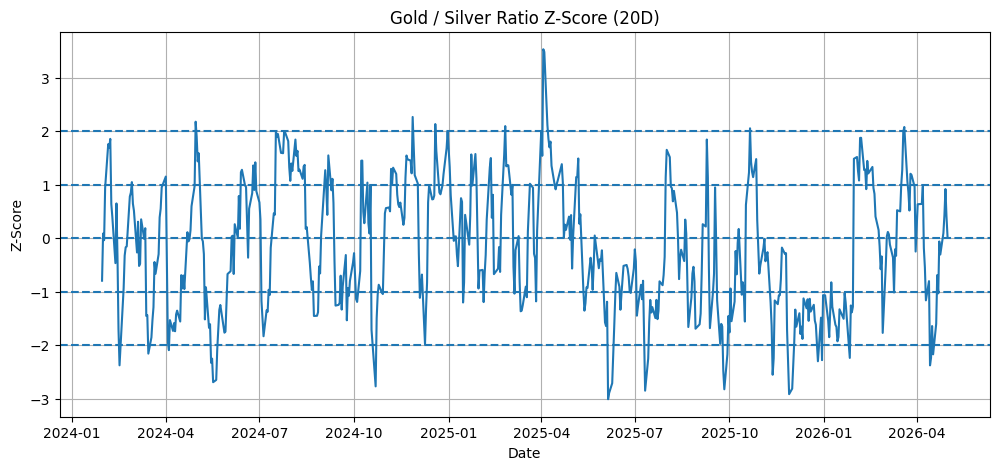

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ratio_zscore_20"])
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Gold / Silver Ratio Z-Score (20D)")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.show()

In [7]:
latest = df.iloc[-1]

print("Latest gold close:", round(latest["gold_close"], 4))
print("Latest silver close:", round(latest["silver_close"], 4))
print("Latest gold/silver ratio:", round(latest["gold_silver_ratio"], 4))
print("Latest 20D z-score:", round(latest["ratio_zscore_20"], 4))

Latest gold close: 4626.3999
Latest silver close: 74.475
Latest gold/silver ratio: 62.1202
Latest 20D z-score: 0.032


In [8]:
if latest["ratio_zscore_20"] > 1:
    print("Gold looks rich versus silver on a short-term basis.")
elif latest["ratio_zscore_20"] < -1:
    print("Silver looks rich versus gold on a short-term basis.")
else:
    print("The ratio is not especially stretched on a short-term basis.")

The ratio is not especially stretched on a short-term basis.


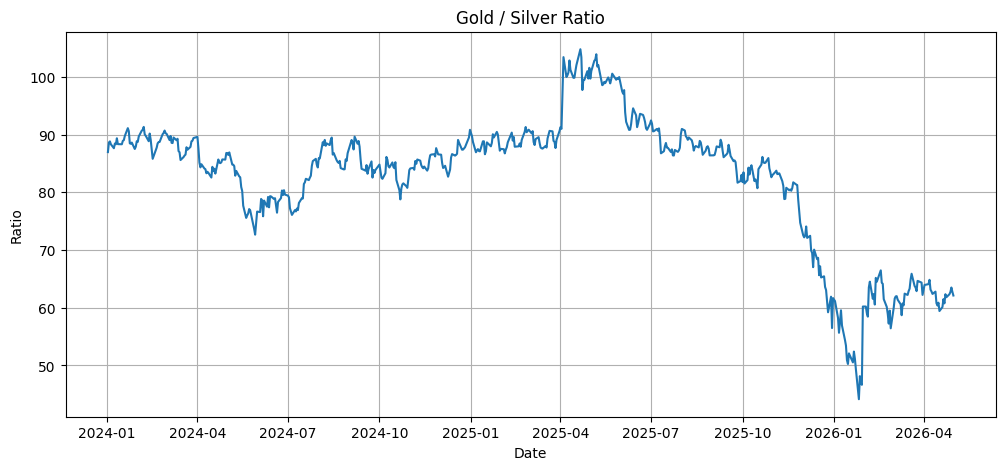

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["gold_silver_ratio"])
plt.title("Gold / Silver Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.savefig("../outputs/charts/gold_silver_ratio.png", bbox_inches="tight")
plt.show()

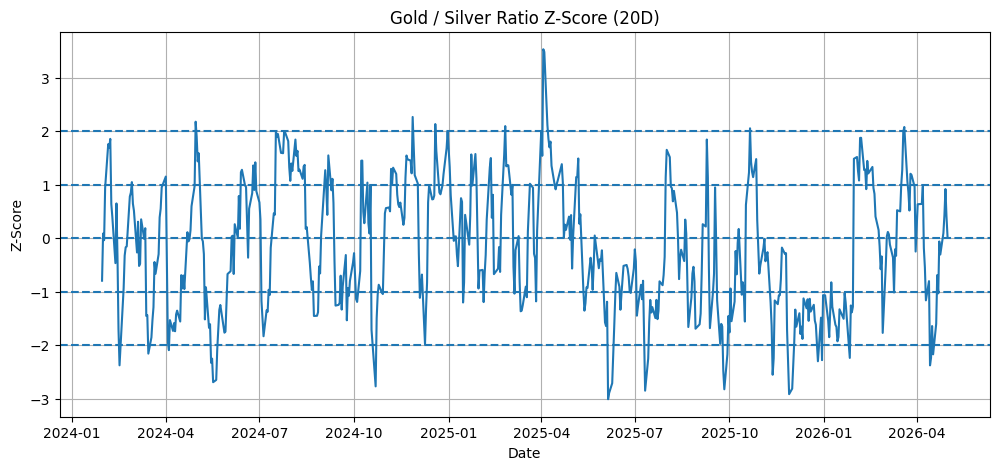

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["ratio_zscore_20"])
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Gold / Silver Ratio Z-Score (20D)")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.savefig("../outputs/charts/gold_silver_ratio_zscore.png", bbox_inches="tight")
plt.show()

In [11]:
for window in [20, 60, 120]:
    df[f"ratio_mean_{window}"] = df["gold_silver_ratio"].rolling(window).mean()
    df[f"ratio_std_{window}"] = df["gold_silver_ratio"].rolling(window).std()
    df[f"ratio_zscore_{window}"] = (
        (df["gold_silver_ratio"] - df[f"ratio_mean_{window}"]) / df[f"ratio_std_{window}"]
    )

In [12]:
latest = df.iloc[-1]

print("Latest gold/silver ratio:", round(latest["gold_silver_ratio"], 4))
print("20D z-score:", round(latest["ratio_zscore_20"], 4))
print("60D z-score:", round(latest["ratio_zscore_60"], 4))
print("120D z-score:", round(latest["ratio_zscore_120"], 4))

Latest gold/silver ratio: 62.1202
20D z-score: 0.032
60D z-score: -0.0601
120D z-score: -0.2028


In [13]:
df["gold_ret"] = df["gold_close"].pct_change()
df["silver_ret"] = df["silver_close"].pct_change()
df["rolling_corr_20"] = df["gold_ret"].rolling(20).corr(df["silver_ret"])

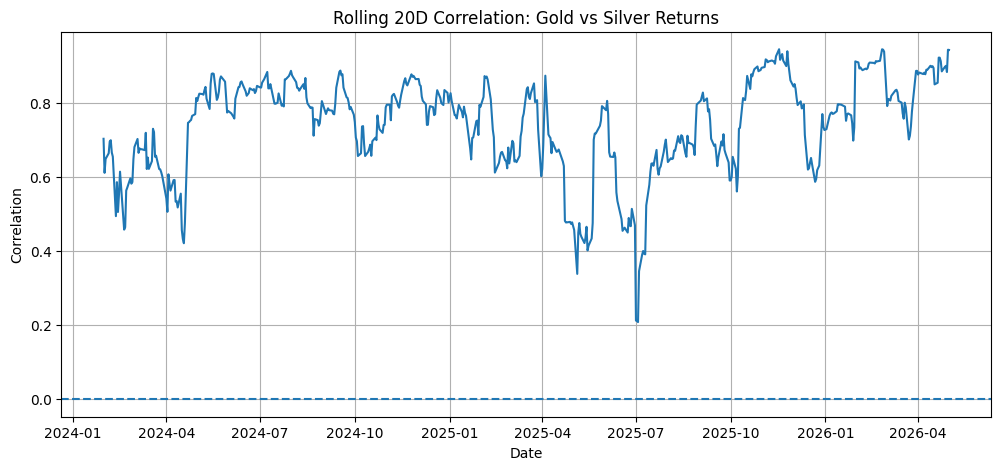

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["rolling_corr_20"])
plt.axhline(0, linestyle="--")
plt.title("Rolling 20D Correlation: Gold vs Silver Returns")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

In [15]:
beta = df[["gold_ret", "silver_ret"]].dropna().cov().iloc[0, 1] / df["silver_ret"].dropna().var()
print("Approximate hedge ratio (gold vs silver):", round(beta, 4))

Approximate hedge ratio (gold vs silver): 0.3552


In [16]:
current_ratio = latest["gold_silver_ratio"]
percentile = (df["gold_silver_ratio"] < current_ratio).mean() * 100
print("Current ratio percentile:", round(percentile, 2), "%")

Current ratio percentile: 8.86 %


## Preliminary pre-trade conclusion

This notebook suggests whether the current gold/silver ratio is statistically stretched on short-, medium-, and longer-term horizons. The key decision variables are:

- whether the ratio z-score is significantly positive or negative
- whether the current ratio sits at an extreme percentile
- whether gold and silver remain sufficiently correlated for a relative-value trade to make sense
- whether the current macro regime supports gold outperforming silver or vice versa

A trade would be more attractive if:
- the ratio is meaningfully stretched
- rolling correlation remains reasonably high
- the macro backdrop supports continuation or mean reversion, depending on the setup

In [17]:
signals = {
    "20D_zscore": latest["ratio_zscore_20"],
    "60D_zscore": latest["ratio_zscore_60"],
    "120D_zscore": latest["ratio_zscore_120"],
    "percentile": percentile,
    "rolling_corr_20": df["rolling_corr_20"].dropna().iloc[-1]
}

signals

{'20D_zscore': np.float64(0.032021747158329186),
 '60D_zscore': np.float64(-0.060124017153467144),
 '120D_zscore': np.float64(-0.20283457439632524),
 'percentile': np.float64(8.858603066439523),
 'rolling_corr_20': np.float64(0.9434274521788046)}

### Honest preliminary verdict

The gold/silver ratio currently sits at a low historical percentile, suggesting that silver has already strongly outperformed gold over the broader sample. However, the 20D, 60D, and 120D z-scores are all close to zero, which indicates that the ratio is not currently stretched relative to recent rolling history. Rolling correlation remains high, so the pair remains structurally suitable for a relative-value trade, but the present statistical signal is weak. At this stage, the trade looks more like a monitored candidate than a high-conviction immediate entry.